# Tutorial: KM-01 Kernels and SVMs

Audience:
- Learners transitioning from linear models to kernel methods and margin-based learning.

Prerequisites:
- Inner products, Gram matrices, and positive semidefinite matrices.
- Convex optimization, Lagrangians, and duality.
- Linear classification and generalization concepts.

Learning goals:
- Visualize why a linear separator fails on nonlinear data.
- Build intuition for kernel matrices as similarity operators.
- Compare linear, polynomial, RBF, and sigmoid SVMs on the same dataset.
- Interpret support vectors, training accuracy, and test accuracy together.


## Outline

1. Create a two-dimensional nonlinear classification dataset.
2. Visualize the dataset and a few kernel Gram matrices.
3. Fit SVMs with four kernels.
4. Compare empirical performance and support-vector counts.
5. Plot decision regions to connect geometry with kernel choice.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

SEED = 17
rng = np.random.default_rng(SEED)
SEED

17

In [2]:
X, y = make_circles(n_samples=500, factor=0.42, noise=0.08, random_state=SEED)

y_signed = 2 * y - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

print('train shape:', X_train.shape)
print('test shape: ', X_test.shape)
print('class balance train:', np.bincount(y_train))

train shape: (350, 2)
test shape:  (150, 2)
class balance train: [175 175]


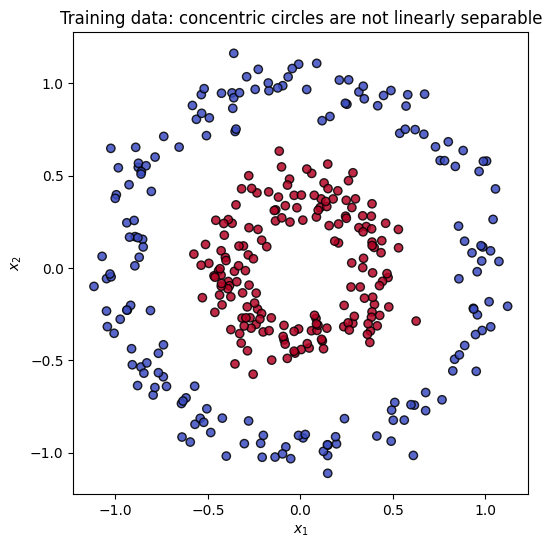

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap='coolwarm',
    edgecolor='k',
    alpha=0.85,
)
ax.set_title('Training data: concentric circles are not linearly separable')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal')
plt.show()

## Kernel matrix intuition

A kernel matrix records pairwise similarities. For a sample of points, different kernels induce visibly different notions of neighborhood and structure. The RBF kernel tends to localize similarity, while the polynomial kernel mixes local and global interactions through dot products and powers.

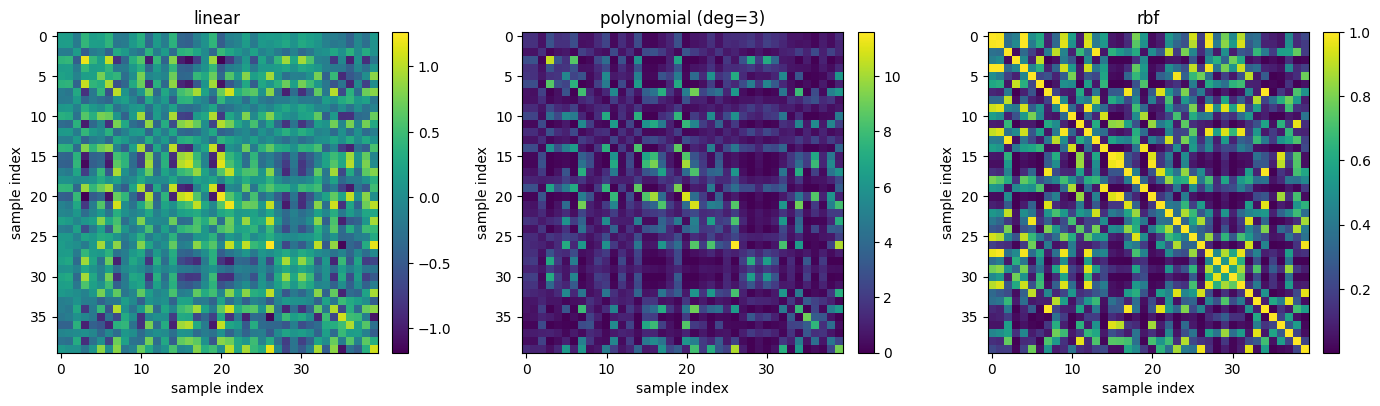

In [4]:
sample_idx = rng.choice(len(X_train), size=40, replace=False)
X_small = X_train[sample_idx]


def linear_kernel(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    return A @ B.T


def polynomial_kernel(A: np.ndarray, B: np.ndarray, degree: int = 3, coef0: float = 1.0) -> np.ndarray:
    return (A @ B.T + coef0) ** degree


def rbf_kernel(A: np.ndarray, B: np.ndarray, gamma: float = 1.5) -> np.ndarray:
    sq_norms_A = np.sum(A ** 2, axis=1, keepdims=True)
    sq_norms_B = np.sum(B ** 2, axis=1, keepdims=True).T
    sq_dists = sq_norms_A + sq_norms_B - 2.0 * (A @ B.T)
    return np.exp(-gamma * sq_dists)


kernel_mats = {
    'linear': linear_kernel(X_small, X_small),
    'polynomial (deg=3)': polynomial_kernel(X_small, X_small, degree=3, coef0=1.0),
    'rbf': rbf_kernel(X_small, X_small, gamma=1.5),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, gram) in zip(axes, kernel_mats.items()):
    im = ax.imshow(gram, cmap='viridis')
    ax.set_title(name)
    ax.set_xlabel('sample index')
    ax.set_ylabel('sample index')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Train SVMs with multiple kernels

We keep preprocessing identical across models by standardizing inputs inside a pipeline. The linear kernel is the baseline. Polynomial and RBF kernels should be better suited to the circular structure, while the sigmoid kernel is included as a comparison point rather than a default recommendation.

In [5]:
models = {
    'linear': Pipeline([
        ('scale', StandardScaler()),
        ('svc', SVC(kernel='linear', C=1.0)),
    ]),
    'polynomial': Pipeline([
        ('scale', StandardScaler()),
        ('svc', SVC(kernel='poly', degree=3, coef0=1.0, C=1.0, gamma='scale')),
    ]),
    'rbf': Pipeline([
        ('scale', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=1.0, gamma=1.5)),
    ]),
    'sigmoid': Pipeline([
        ('scale', StandardScaler()),
        ('svc', SVC(kernel='sigmoid', C=1.0, coef0=0.0, gamma='scale')),
    ]),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    svc = model.named_steps['svc']
    results.append({
        'kernel': name,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'support_vectors': int(svc.n_support_.sum()),
    })

results

[{'kernel': 'linear',
  'train_accuracy': 0.6114285714285714,
  'test_accuracy': 0.5,
  'support_vectors': 336},
 {'kernel': 'polynomial',
  'train_accuracy': 1.0,
  'test_accuracy': 1.0,
  'support_vectors': 11},
 {'kernel': 'rbf',
  'train_accuracy': 1.0,
  'test_accuracy': 1.0,
  'support_vectors': 37},
 {'kernel': 'sigmoid',
  'train_accuracy': 0.5971428571428572,
  'test_accuracy': 0.64,
  'support_vectors': 207}]

In [6]:
results_sorted = sorted(results, key=lambda row: row['test_accuracy'], reverse=True)
for row in results_sorted:
    print(
        f"{row['kernel']:>10} | train={row['train_accuracy']:.3f} | "
        f"test={row['test_accuracy']:.3f} | support_vectors={row['support_vectors']}"
    )

polynomial | train=1.000 | test=1.000 | support_vectors=11
       rbf | train=1.000 | test=1.000 | support_vectors=37
   sigmoid | train=0.597 | test=0.640 | support_vectors=207
    linear | train=0.611 | test=0.500 | support_vectors=336


On this dataset, nonlinear kernels should outperform the linear baseline because the target boundary is topologically circular rather than approximately affine. Support-vector counts also help show how much of the training set each model needs to anchor its boundary.

In [7]:
def plot_decision_surface(ax, model, X, y, title: str) -> None:
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz > 0, levels=1, alpha=0.2, cmap='coolwarm')
    ax.contour(xx, yy, zz, levels=[-1, 0, 1], colors=['#666666', 'black', '#666666'], linestyles=['--', '-', '--'])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=25)

    svc = model.named_steps['svc']
    support_idx = svc.support_
    support_points = model.named_steps['scale'].transform(X_train)[support_idx]
    original_support = X_train[support_idx]
    ax.scatter(original_support[:, 0], original_support[:, 1], s=90, facecolors='none', edgecolors='gold', linewidths=1.4)

    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')

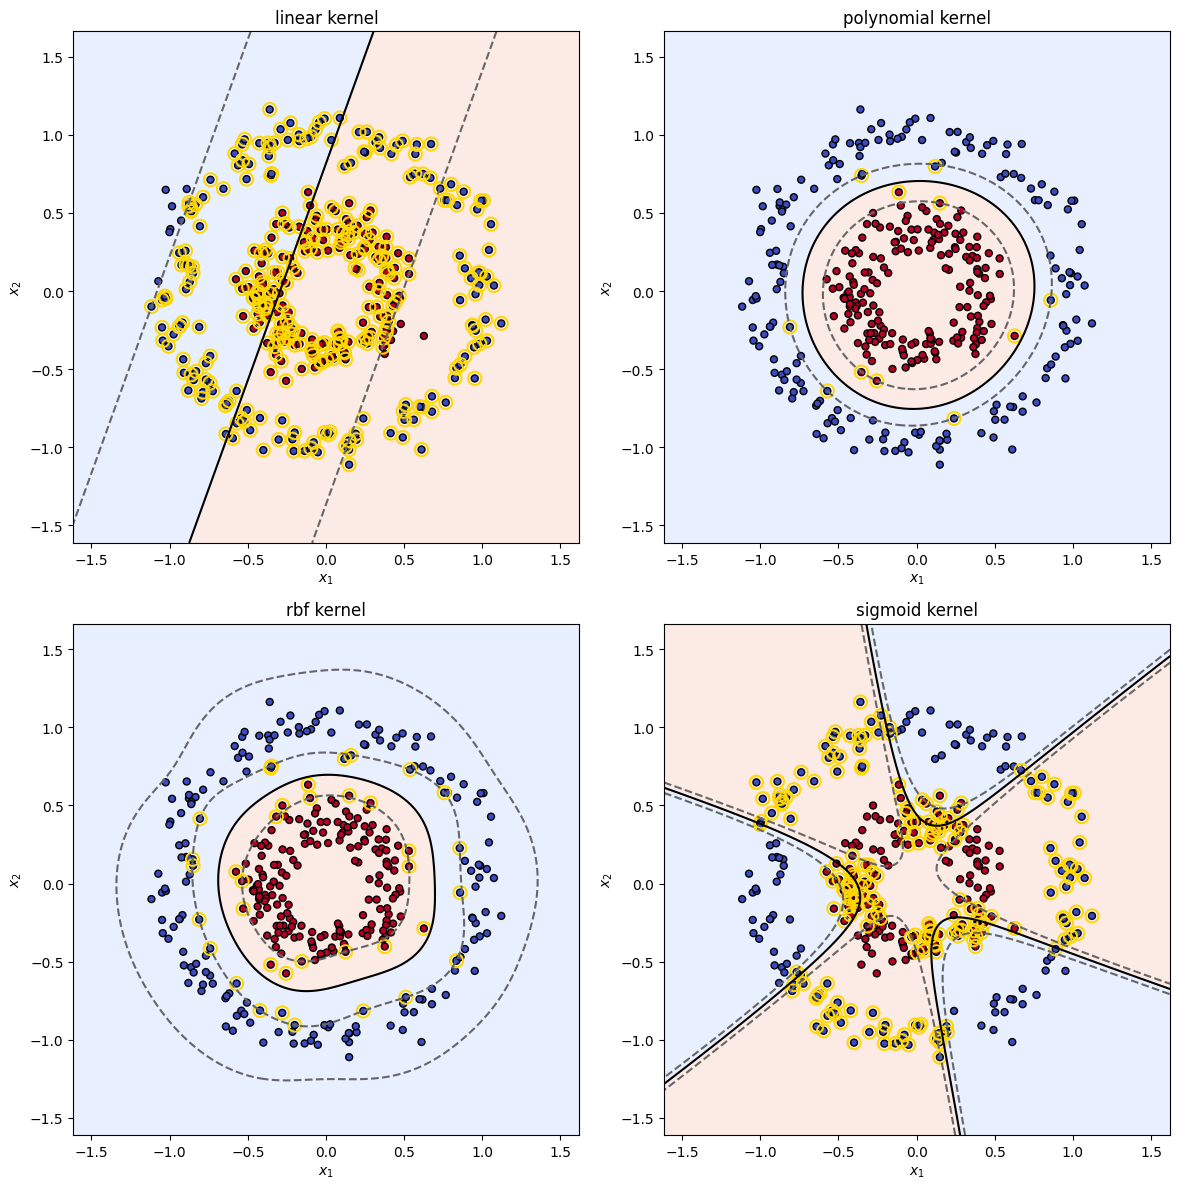

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, (name, model) in zip(axes.ravel(), fitted_models.items()):
    plot_decision_surface(ax, model, X_train, y_train, title=f'{name} kernel')
plt.tight_layout()
plt.show()

## Interpretation

- The linear SVM can only carve out a single affine boundary, so it underfits the circular geometry.
- The polynomial kernel can bend the boundary through global interaction terms, but its shape is still constrained by the chosen degree.
- The RBF kernel usually tracks the circles most naturally because similarity decays with distance.
- The sigmoid kernel is less stable as a default choice and often lags the better-matched kernels.

Questions to check your understanding:

1. Which kernel achieved the best test accuracy, and does that match the decision-boundary plot?
2. Did the best-performing kernel use more support vectors than the linear baseline?
3. How would changing `C` or `gamma` affect smoothness versus flexibility?
